# BE 3 : unsupervised machine learning for imaging
### Focus on hyperspectral imaging

In this lab, we will apply some techniques of unsupervised machine learning for image processing/computer vision. We first consider an already pre-processed hyperspectral AVIRIS image. We will try to apply clustering algorithms and factor analysis techniques to this image, in order to get the spectra of elements (grass, soil, water, etc), and their spatial repartition in the image.

## 1. Read and visualize the hyperspectral image

First load some modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy.io as sio
from sklearn.cluster import KMeans
from numpy import linalg as LA
from sklearn.decomposition import NMF

Now download the AVIRIS image. Be careful it has not been compressed to it is more than 300 Mo big.

In [3]:
!wget https://nextcloud.isae.fr/index.php/s/GtXPpJ8xiDSrFFo/download # Adapt if your OS is not a Linux
!ls

--2026-03-09 15:43:20--  https://nextcloud.isae.fr/index.php/s/GtXPpJ8xiDSrFFo/download
Résolution de nextcloud.isae.fr (nextcloud.isae.fr)… 10.132.11.2
Connexion à nextcloud.isae.fr (nextcloud.isae.fr)|10.132.11.2|:443… connecté.
requête HTTP transmise, en attente de la réponse… 303 See Other
Emplacement : https://nextcloud.isae.fr/public.php/dav/files/GtXPpJ8xiDSrFFo/?accept=zip [suivant]
--2026-03-09 15:43:20--  https://nextcloud.isae.fr/public.php/dav/files/GtXPpJ8xiDSrFFo/?accept=zip
Réutilisation de la connexion existante à nextcloud.isae.fr:443.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 375848526 (358M) [application/octet-stream]
Sauvegarde en : « download »

download            100%[===================>] 358,44M  21,8MB/s    ds 15s     

2026-03-09 15:43:35 (24,5 MB/s) — « download » sauvegardé [375848526/375848526]

Lab3_unsupervised.ipynb download
barbara.pgm             tulip.ppm


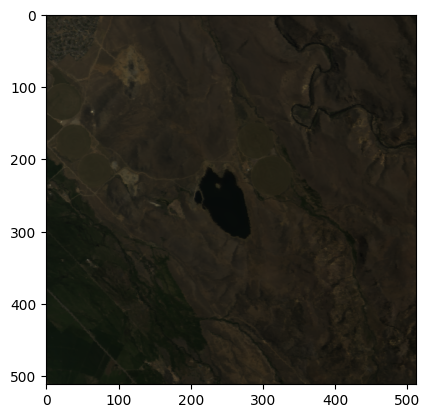

In [5]:
# Load test data
aviris = sio.loadmat('aviris.mat')
img = aviris['aviris']

# RGB bands to display
bands = (26, 20, 11)

# Display image
plt.imshow(img[:,:,bands])
plt.show()

We can observe that the contrast on the image is very poor. Yet the image dynamics is (0,1), this is not a problem of normalization or type. Actually, and this is often the case with satellite images, some pixels in some bands have saturated, so their values is very high, which lowers the constrast of the rest of the image. 
We will thus make a nonlinear scaling, by simply clipping the lower and top 1% of values.

(array([1., 0., 1., ..., 0., 0., 2.], shape=(1371,)),
 array([1.10885436e-07, 7.29505488e-04, 1.45890009e-03, ...,
        9.98541322e-01, 9.99270716e-01, 1.00000011e+00], shape=(1372,)),
 <BarContainer object of 1371 artists>)

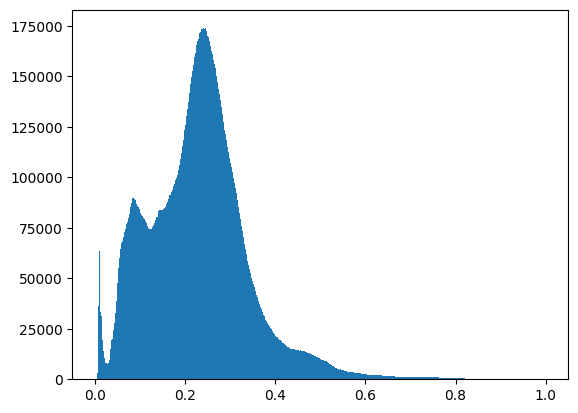

In [6]:
#Display histogram
plt.hist(img.flatten(), bins='auto')

In [7]:
def normalize_img(img):
    res = img;
    for k in np.arange(3):
        vmin = np.percentile(res[:,:,k],1)
        vmax = np.percentile(res[:,:,k],99)
        res[:,:,k] = (res[:,:,k] - vmin) / (vmax - vmin)
        np.clip(res[:,:,k], 0., 1., res[:,:,k]) # in-place clipping
    return res

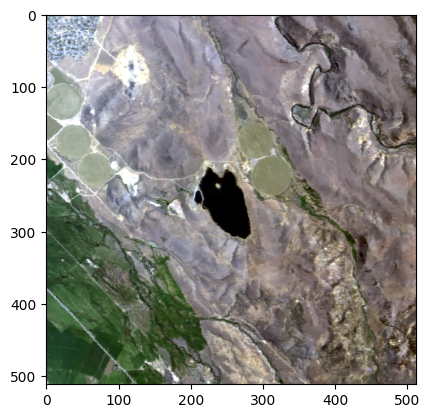

In [8]:
# Normalize and increase contrast, then display
plt.imshow(normalize_img(img[:,:,bands]))
plt.show()

Do not forget this is a hyperspectral image, where each pixel is a spectrum made of many spectral bands. Let us plot some random spectra of this image.

In [9]:
def plot_spectra(img, idx):
    s = img.shape
    img = img.reshape(s[0]*s[1], s[2])
    plt.plot(np.transpose(img[idx,:]))
    plt.show()
    return

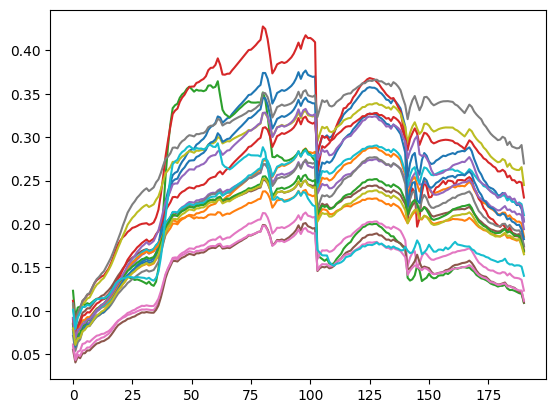

In [10]:
#Get 20 random pixels
idx_spectra = np.random.randint(low=0, high=np.prod(img.shape[0:1]), size=20)

#Display the corresponding spectra
plot_spectra(img,idx_spectra)

## 2. K-means segmentation

Let us apply a well-known clustering algorithm to the pixels of the image.

In [25]:
# Reshape image into 2 dimensions : space x spectrum
s = img.shape
img2 = img.reshape(s[0]*s[1], s[2])

# Apply K-means
km = KMeans(n_clusters=8)
km.fit(img2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


We can now visualize the segmentation: the centers will be the spectra of the different elements, and the labels with give the spatial repartition of those elements in the image.

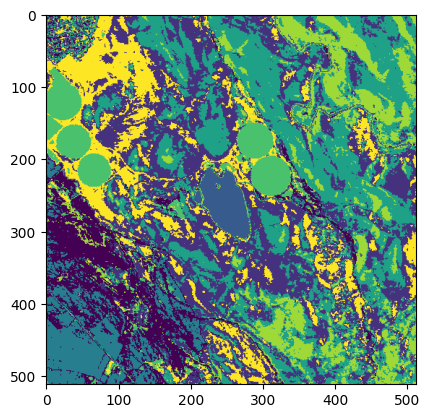

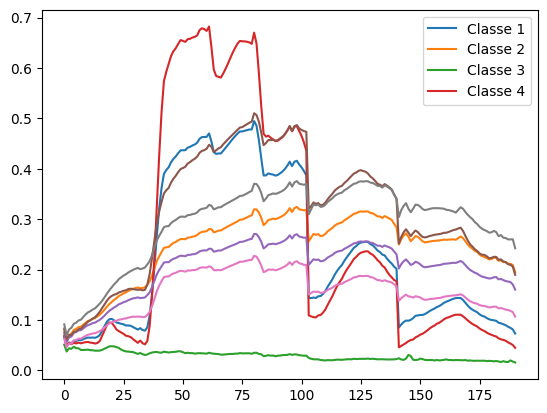

In [26]:
# Display segmentation result
img_km = km.labels_
plt.imshow(img_km.reshape(s[0], s[1]))
plt.show()

# Display centroids
centers = km.cluster_centers_.transpose()
plt.plot(centers)
plt.gca().legend(('Classe 1','Classe 2','Classe 3','Classe 4'))
plt.show()


### Get the best K
It seems in the previous example that soil, vegetation and water have been correctly identified. But we might obtain better results with a smaller or a larger number of classes. 

<b> Exercise</b>
- Make K varry and observe the results
- Compute the K-means loss function (intra-class variance) as a function of K, and estimate the inflexion point (Elbow method)


In [ ]:
# Your turn

### Clustering for non-uniform vector quantization

Suppose we want to quantize this hyperspectral image, where originally each pixel was coded on 12 bits for each of the 185 bands. Finding an adaptive quantization that minimizes the error is very similar to a clustering problem. 

<b> Exercise</b>
- Make a clustering with a few hundreads of clusters
- Set each pixel to the center of its corresponsing cluster
- Compute the error (MSE and/or PSNR) and visualize the RGB image
- What is the limitation of such an approach?

In [ ]:
# Your turn

## 3. Dimension reduction with PCA
We will apply a principal component analysis in the pixel's space. Remember, PCA is a core technique in ML, it brings:
- Dimension reduction
- Denoising
- Decorrelation
- Variable selection
- Easy visualization
- etc

We will implement our own PCA but of course we could use sklearn as well.

/var/folders/gd/kf1g0d9s227gqylz3d572v2m0000gn/T/ipykernel_36818/3887548340.py:16: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(lambdas))


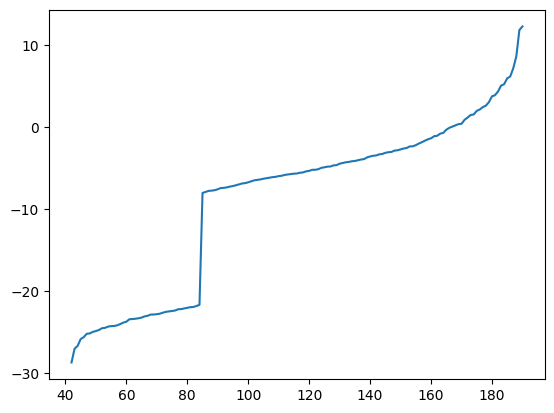

(191,)


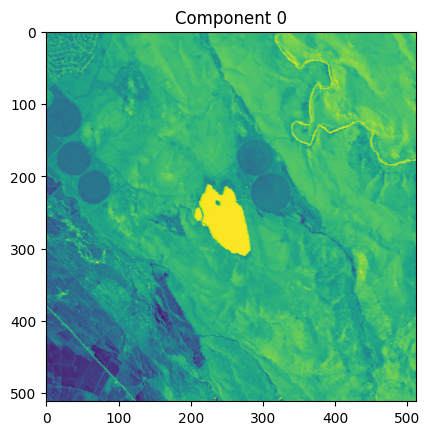

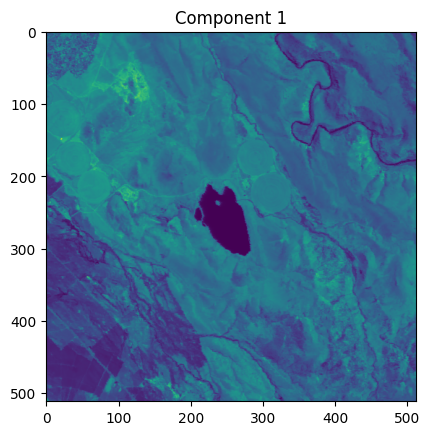

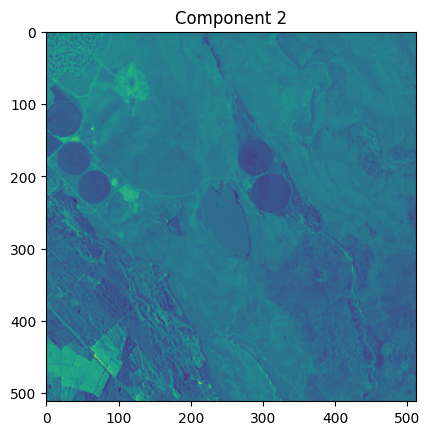

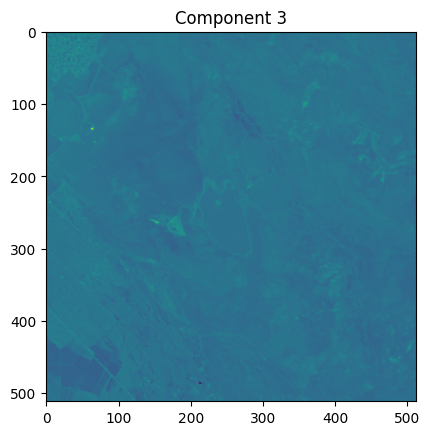

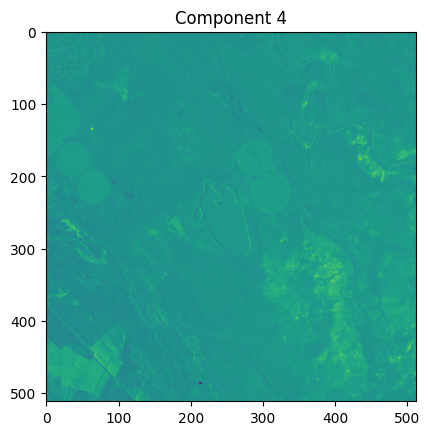

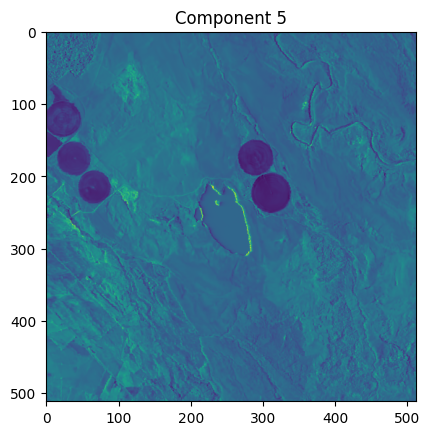

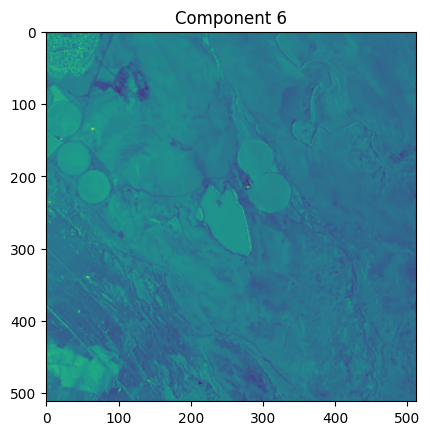

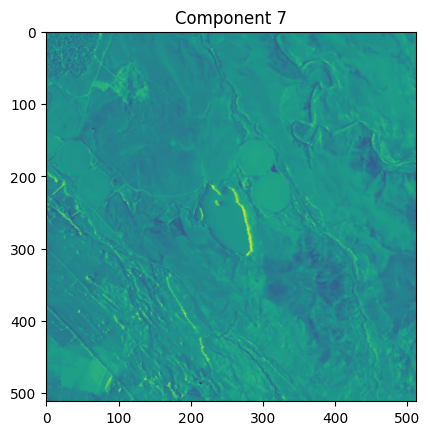

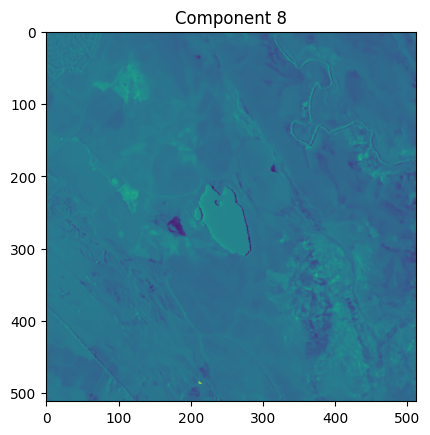

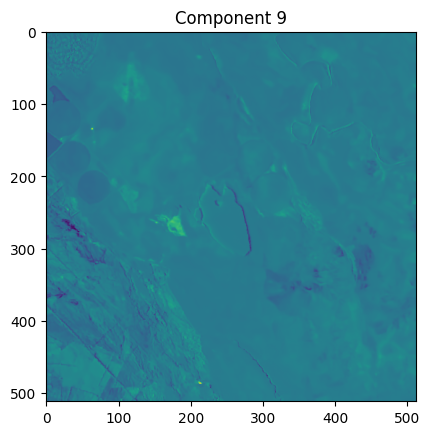

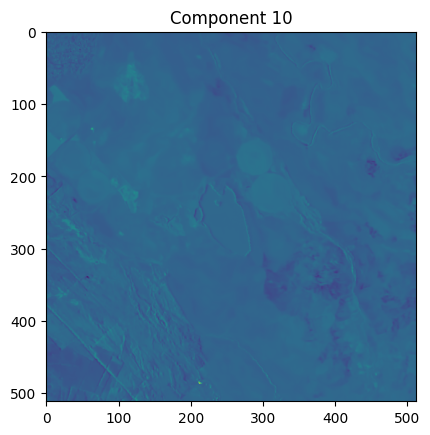

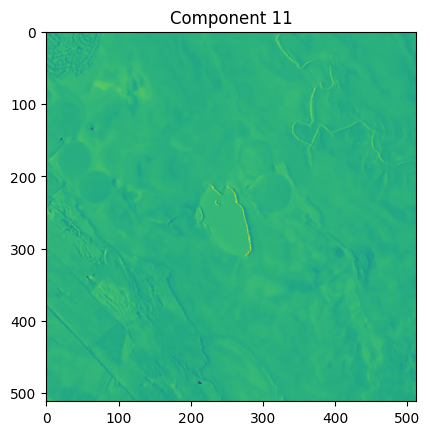

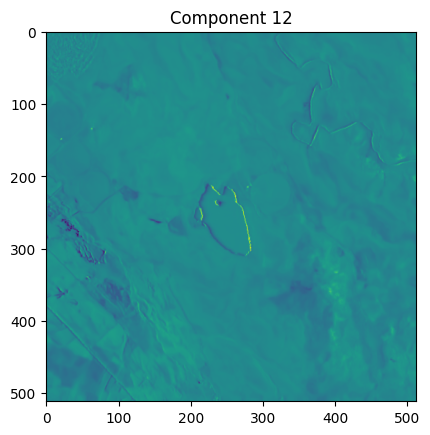

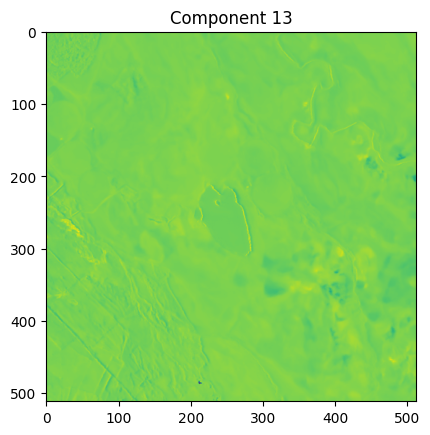

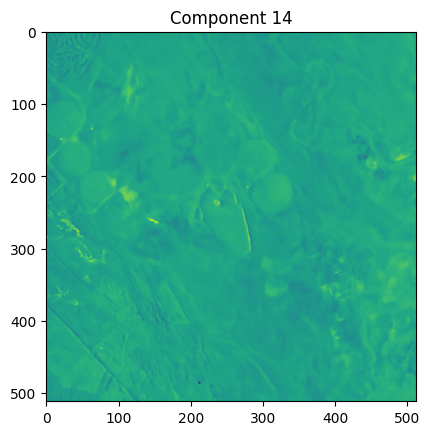

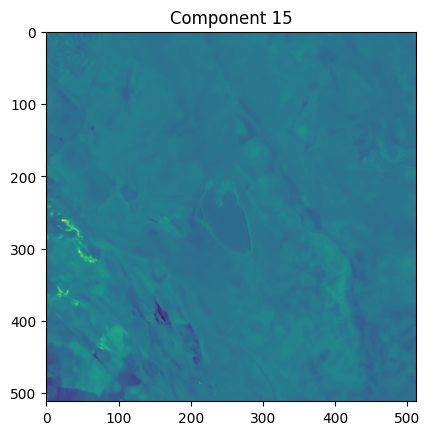

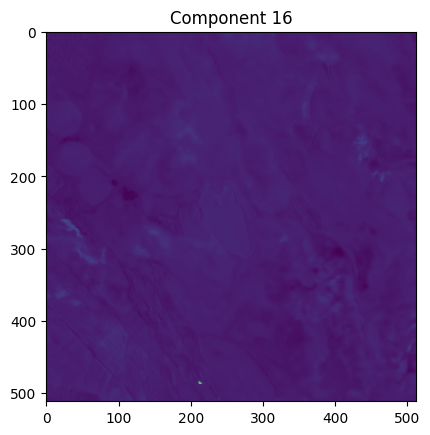

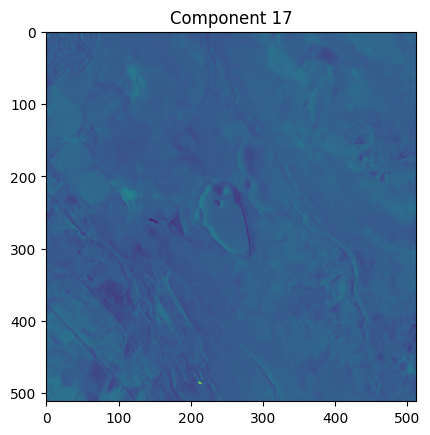

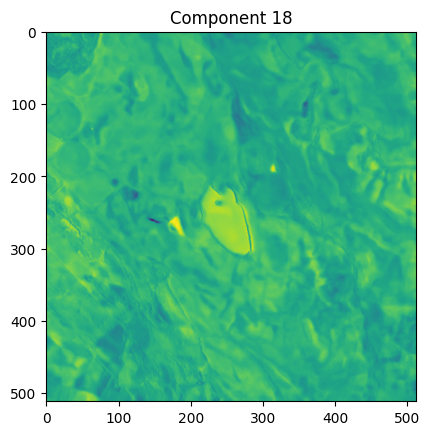

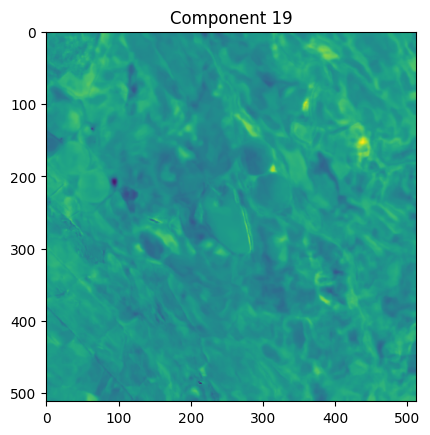

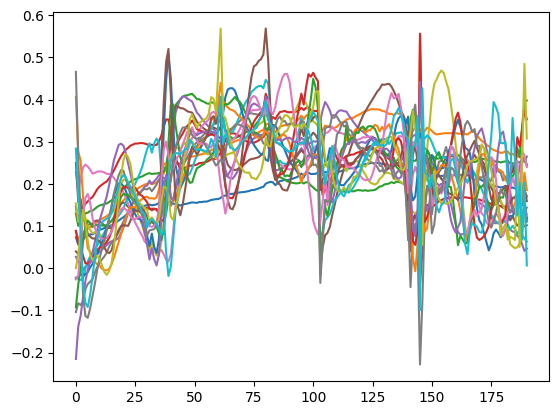

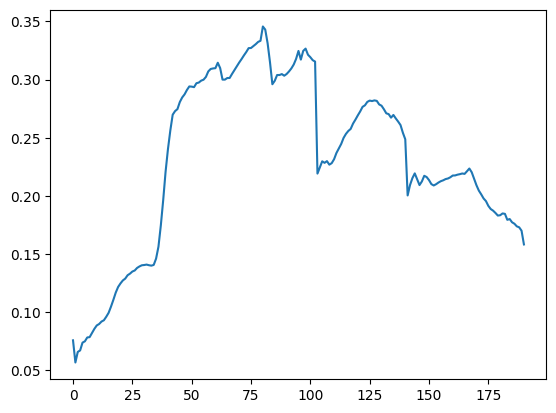

In [27]:
# Load test data
aviris = sio.loadmat('aviris.mat')
img = aviris['aviris']
s = img.shape
img2 = img.reshape(s[0]*s[1], s[2])

# Compute sample covariance matrix
mu = np.mean(img2, axis=0)
img2 -= mu
cov = np.matmul(np.transpose(img2), img2)

# Get eigen values and vectors
lambdas, U = LA.eigh(cov)

# Plot eigenvalues
plt.plot(np.log(lambdas))
plt.show()

# Map image to the first 20 components
U = U[:,-1:-21:-1]
y = np.matmul(img2,U)
y = np.reshape(y, [s[0], s[1], 20])
print(mu.shape)

# Display corresponding images
for k in range(20):
    plt.imshow(y[:,:,k])
    plt.title('Component {}'.format(k))
    plt.show()
    
# Display the spectra
plt.plot(np.transpose(mu+np.transpose(U)))
plt.show()
plt.plot(mu)
plt.show()

### Exercise
Get the approximation of the data when projecting back in the original image space, and compute the MSE.

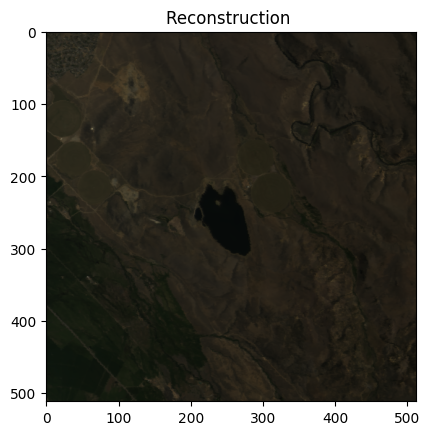

In [29]:
# TODO

X = np.matmul(y , np.transpose(U))
X = X + mu

plt.imshow(X[:,:,bands])
plt.title('Reconstruction ')
plt.show()


## 4. Factorial analysis with nonnegative matrix factorization

We will try here to "unmix" the components of the hyperspectral image. Indeed, in practice the spatial resolution of AVIRIS is low, so most of the pixels do not contain pure components, but an approximately linear mixing of them. With NMF, we will try to identify both the element's spectra and their spatial repartition.

<b>Exercise</b>: 
- Apply NMF to the image
- Display the spectra and the coefficients (maps)
- Compare with the clustering results
- Compare with the PCA results
- In what sense is NMF a "soft-clustering" approach?

In [30]:
# TODO
from sklearn.decomposition import NMF

img = aviris['aviris']
s = img.shape
img2 = img.reshape(s[0]*s[1], s[2])

model = NMF(n_components=2, init='random', random_state=0)
W = model.fit_transform(img2)
H = model.components_

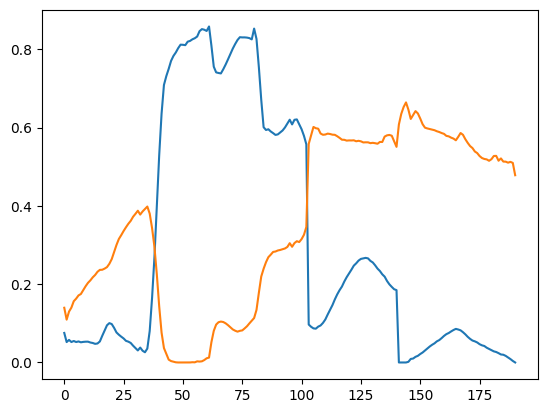

In [31]:
plt.plot(H.transpose())
plt.show()

## 5. Applications on standard grayscale or RGB images
We will now explore more traditional applications of unsupervised ML to imagery. Load the given tulip image.

### Patch-based image processing
Factor analysis or dimension reduction is not directly possible on RGB images, since the pixels live in a 3-dimensional space. But we can do a lot by working in the patch space instead of the pixel space. The following code transforms learns a dictionary from a noisy grayscale image, which is a powerful method for denoising.

In [32]:
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import extract_patches_2d
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

In [33]:
# Get the image and the patches
img = plt.imread('barbara.pgm')

# Creates a noisy version
noisy = img + np.random.normal(0,10,img.shape)
height, width = img.shape

patch_size = (7, 7)
data = extract_patches_2d(noisy, patch_size)
data = data.reshape(data.shape[0], -1)
dmean = np.mean(data, axis=0)
data -= dmean
dstd = np.std(data, axis=0)
data /= dstd

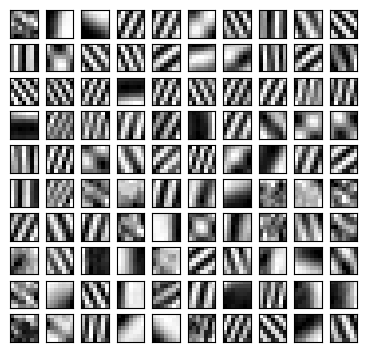

In [35]:
# Learn and displays the dictionary
dico = MiniBatchDictionaryLearning(n_components=100, alpha=1, max_iter=500)
V = dico.fit(data).components_

plt.figure(figsize=(4.2, 4))
for i, comp in enumerate(V[:100]):
    plt.subplot(10, 10, i + 1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r,
               interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.subplots_adjust(0.08, 0.02, 0.92, 0.85, 0.08, 0.23)

In [36]:
# Reconstruct the image
# Get the code (coefficients in each of the atoms)
code = dico.transform(data)
patches = np.dot(code, V)

# De-patchify
patches += dmean
patches = patches.reshape(len(data), *patch_size)
reconstruction = reconstruct_from_patches_2d(patches, (height, width))

Text(0.5, 1.0, 'Denoised image')

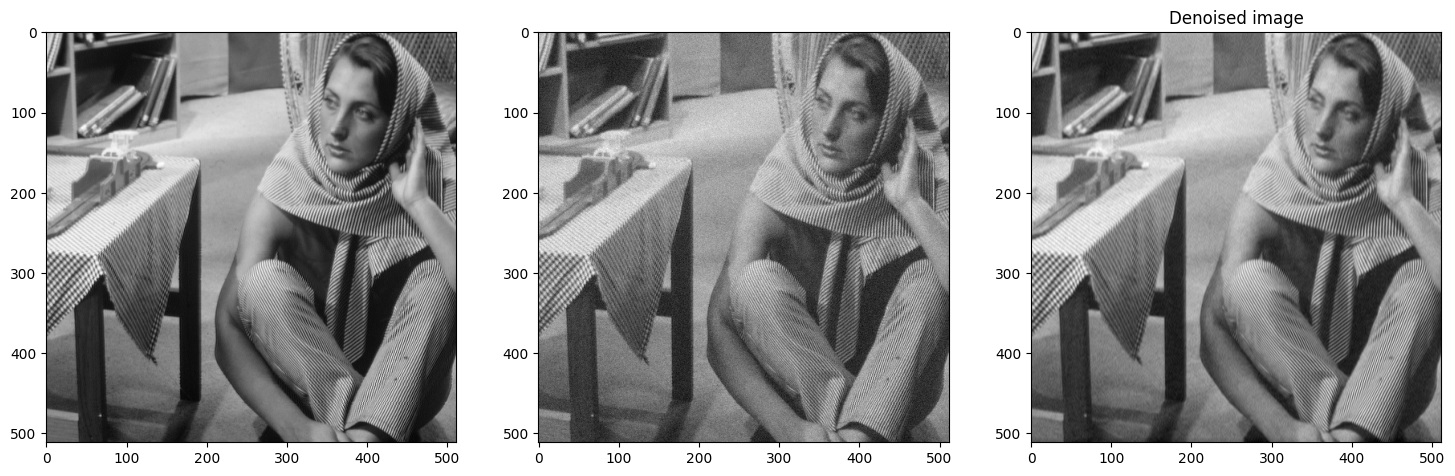

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))
axes[0].imshow(img, cmap=plt.get_cmap('gray'))
plt.title('Original image')
axes[1].imshow(noisy, cmap=plt.get_cmap('gray'))
plt.title('Noisy image')
axes[2].imshow(reconstruction, cmap=plt.get_cmap('gray'))
plt.title('Denoised image')


We see that the reconstructed image contains less noise. But note that we have learned the dictionary from the noisy image, which is not a very good idea. 

<b>Exercise</b>: Instead, try to learn the dictionary from a different but clean image.

In [ ]:
# Your turn